A competition where students have to segment images pet animals, this is just a dummy baseline

Comp link: https://www.kaggle.com/t/b97779916da642c7a4228e6bce44856a

Found dataset:
/kaggle/input/competitions/pet-segmentation

Local dummy train Dice: 0.67407
Checked masks: 800

Saved submission.csv

Null check:
Id               0
EncodedPixels    0
dtype: int64


,Id,EncodedPixels
0,test_00000,2106 15 2230 23 2355 29 2481 33 2607 37 2733 4...
1,test_00001,2106 15 2230 23 2355 29 2481 33 2607 37 2733 4...
2,test_00002,2106 15 2230 23 2355 29 2481 33 2607 37 2733 4...
3,test_00003,2106 15 2230 23 2355 29 2481 33 2607 37 2733 4...
4,test_00004,2106 15 2230 23 2355 29 2481 33 2607 37 2733 4...


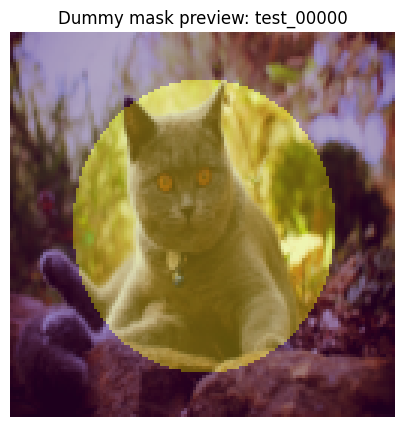

In [1]:
# ============================================================
# Dummy baseline for Pet Pixels segmentation challenge
#
# Predicts a centered ellipse mask for every test image.
#
# Output:
#   submission.csv
#
# Empty masks use "1 0" so Kaggle does not read null values.
# ============================================================

import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image


# ============================================================
# CONFIG
# ============================================================

IMAGE_SIZE = 128

ID_COL = "Id"
TARGET_COL = "EncodedPixels"

EMPTY_RLE = "1 0"

DUMMY_MODE = "ellipse"
# Options:
#   "ellipse"        = centered oval mask
#   "rectangle"      = centered rectangle mask
#   "all_foreground" = full image mask
#   "empty"          = empty mask


# ============================================================
# Find dataset automatically
# ============================================================

def find_dataset_root():
    for root, dirs, files in os.walk("/kaggle/input"):
        root_path = Path(root)

        if (
            "sample_submission.csv" in files
            and "test" in dirs
        ):
            test_images = root_path / "test" / "images"

            if test_images.exists():
                try:
                    sample = pd.read_csv(root_path / "sample_submission.csv", nrows=5)

                    if {ID_COL, TARGET_COL}.issubset(set(sample.columns)):
                        return root_path

                except Exception:
                    pass

    raise FileNotFoundError(
        "Could not find dataset folder with sample_submission.csv and test/images."
    )


DATA_DIR = find_dataset_root()
TEST_IMAGE_DIR = DATA_DIR / "test" / "images"

print("Found dataset:")
print(DATA_DIR)


# ============================================================
# RLE encode
# ============================================================

def rle_encode(mask):
    """
    Encode binary mask using 1-indexed row-major RLE.

    Empty mask returns "1 0" instead of blank.
    """

    pixels = mask.astype(np.uint8).flatten(order="C")

    if pixels.sum() == 0:
        return EMPTY_RLE

    pixels = np.concatenate([[0], pixels, [0]])

    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] = runs[1::2] - runs[::2]

    encoded = " ".join(str(x) for x in runs)

    if encoded.strip() == "":
        return EMPTY_RLE

    return encoded


# ============================================================
# Dummy mask generators
# ============================================================

def make_empty_mask(h, w):
    return np.zeros((h, w), dtype=np.uint8)


def make_all_foreground_mask(h, w):
    return np.ones((h, w), dtype=np.uint8)


def make_rectangle_mask(h, w):
    mask = np.zeros((h, w), dtype=np.uint8)

    y1 = int(h * 0.18)
    y2 = int(h * 0.90)
    x1 = int(w * 0.18)
    x2 = int(w * 0.82)

    mask[y1:y2, x1:x2] = 1

    return mask


def make_ellipse_mask(h, w):
    yy, xx = np.mgrid[0:h, 0:w]

    cy = h / 2.0
    cx = w / 2.0

    ry = h * 0.38
    rx = w * 0.34

    ellipse = ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2 <= 1.0

    return ellipse.astype(np.uint8)


def make_dummy_mask(h, w):
    if DUMMY_MODE == "empty":
        return make_empty_mask(h, w)

    if DUMMY_MODE == "all_foreground":
        return make_all_foreground_mask(h, w)

    if DUMMY_MODE == "rectangle":
        return make_rectangle_mask(h, w)

    if DUMMY_MODE == "ellipse":
        return make_ellipse_mask(h, w)

    raise ValueError(f"Unknown DUMMY_MODE: {DUMMY_MODE}")


# ============================================================
# Optional local validation on train masks
# ============================================================

def dice_score(y_true, y_pred):
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)

    intersection = np.logical_and(y_true, y_pred).sum()
    denom = y_true.sum() + y_pred.sum()

    if denom == 0:
        return 1.0

    return 2.0 * intersection / denom


train_mask_dir = DATA_DIR / "train" / "masks"

if train_mask_dir.exists():
    scores = []

    mask_paths = sorted([
        p for p in train_mask_dir.iterdir()
        if p.suffix.lower() in [".png", ".jpg", ".jpeg"]
    ])

    for path in mask_paths:
        true_mask = Image.open(path).convert("L")
        true_mask = true_mask.resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST)
        true_mask = np.array(true_mask)
        true_mask = (true_mask > 127).astype(np.uint8)

        pred_mask = make_dummy_mask(IMAGE_SIZE, IMAGE_SIZE)

        scores.append(dice_score(true_mask, pred_mask))

    print()
    print(f"Local dummy train Dice: {np.mean(scores):.5f}")
    print(f"Checked masks: {len(scores)}")


# ============================================================
# Create submission
# ============================================================

sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

rows = []

for _, row in sample_submission.iterrows():
    image_id = str(row[ID_COL])

    image_path = TEST_IMAGE_DIR / f"{image_id}.png"

    if image_path.exists():
        image = Image.open(image_path).convert("RGB")
        w, h = image.size
    else:
        h, w = IMAGE_SIZE, IMAGE_SIZE

    mask = make_dummy_mask(h, w)
    encoded = rle_encode(mask)

    if pd.isna(encoded) or str(encoded).strip() == "":
        encoded = EMPTY_RLE

    rows.append({
        ID_COL: image_id,
        TARGET_COL: encoded,
    })


submission = pd.DataFrame(rows)

submission[TARGET_COL] = (
    submission[TARGET_COL]
    .fillna(EMPTY_RLE)
    .astype(str)
    .replace({"": EMPTY_RLE, "nan": EMPTY_RLE, "NaN": EMPTY_RLE})
)

submission.to_csv("submission.csv", index=False)

print()
print("Saved submission.csv")
print()
print("Null check:")
print(submission.isna().sum())
display(submission.head())


# ============================================================
# Show one example mask
# ============================================================

try:
    import matplotlib.pyplot as plt

    example_id = str(sample_submission.iloc[0][ID_COL])
    example_img = Image.open(TEST_IMAGE_DIR / f"{example_id}.png").convert("RGB")
    example_mask = make_dummy_mask(example_img.size[1], example_img.size[0])

    plt.figure(figsize=(5, 5))
    plt.imshow(example_img)
    plt.imshow(example_mask, alpha=0.35)
    plt.title(f"Dummy mask preview: {example_id}")
    plt.axis("off")
    plt.show()

except Exception as e:
    print("Preview skipped:", e)